In [1]:
import numpy as np
import qutip as qt
import scipy.linalg as LA
# from numpy import linalg as LA
import matplotlib.pyplot as plt
from scipy.integrate import quad_vec
import os
import pickle
from sympy import *
import matplotlib.cm as cm
from scipy.optimize import root
from cmath import *
# rc( 'font' , **{ 'family':  'serif ’ , ’ serif ’:[ ’Palatino ’]})


In [ ]:
unit= 10
t1,t2= 1,2
S = np.array([[0,  t1], 
                  [ t1 , 0]])
    
T = np.array([[0, 0], [ t2, 0]])

# Create sparse diagonal matrices   

TN_up = np.eye(unit , k=1)
TN_down = np.eye(unit , k=-1)
IN = np.eye(unit )

# Use kron (Kronecker product) to create the tensor products
IN_S = np.kron(IN, S)
TN_T_up = np.kron(TN_up, T)
TN_T_down = np.kron(TN_down, T.T)
H= IN_S + TN_T_up + TN_T_down
_,_,H=LA.eig(H)

In [2]:
def ensure_directory_exists(home):
    if not os.path.exists(home):
        os.makedirs(home)

In [3]:
# OBC/PBC approach ( Liapunov equation)

#Ground state of SSH Hamiltonian in position base 

def Hamiltonian(L, t1, mu, Type):
    unit = 2*L
    # Define the submatrices
    IN = mu*np.eye(unit )
    TN_up = t1*np.eye(unit , k=1)
    TN_down = t1*np.eye(unit , k=-1)


    # Assemble the Hamiltonian
    # o= OBC
    if Type == "open":
        H = IN+ TN_up + TN_down
    # PBC condition
    else:
        H= IN +TN_up + TN_down
        H[-1,0]= t1
        H[0,-1]= t1
        
    

    return H



In [4]:
# Unitary evolution of covariance matrix
def Gamma_t(rho_0, H, T):
    U_conj= LA.expm(1j*H.T*T)
    U_T= LA.expm(-1j*H.T*T)
    rho_t= U_conj@rho_0@U_T
    return rho_t

In [5]:
# Von Neuman Entropy ( avoid computing log(0) )
def xlogx(x):
    x = np.asarray(x)
    out = np.zeros_like(x, dtype=float)
    mask = x > 0
    out[mask] = -x[mask] * np.log(x[mask]) -(1-x[mask]) * np.log(1-x[mask])
    return out

In [6]:
def Bipartite_EE(rho_0, H, T):
    N= rho_0.shape[0]//2
    N1=90

    U_conj= LA.expm(1j*H.T*T)
    U_T= LA.expm(-1j*H.T*T)
    rho_t= U_conj@rho_0@U_T
    EIGen, _ = LA.eig(rho_t[N:N+N1,N:N+N1])
#     EIGen, _ = LA.eig(rho_t[N:,N-10:N+10])
    rho_log_rho = np.sum(xlogx(EIGen))
    return np.real(rho_log_rho)

In [7]:
#Inhomogeneous initial state
def Gamma_0(L):
    unit= L
    n1= np.array([[0,0],[0,1]])
    rho_0L= np.zeros([2*L,2*L]) #Left side is the vacuum
    nell_indices= np.array([0 if i%2 ==0 else 1 for i in range(unit)])
    rho_0R= np.kron(n1,np.diag(nell_indices)) # Right side is the Nell state
    rho_0= rho_0L +rho_0R
    return rho_0


In [8]:
import numpy as np

def wigner_all_x(GAMMA, k, t):
    """
    Compute W(k, x; t) for all x and a vector (or scalar) of k.

    GAMMA: array (T, N, N)
    k: float or array-like of shape (K,)  - arbitrary k values
    t: int (time index)

    Returns:
        W: shape (K, N) if k is array, else shape (N,)
           where W[i, x] = sum_s exp(1j*k[i]*s) * GAMMA[t, x-s, x+s]
    """
    GAMMA_t = GAMMA[t]             # (N, N)
    N = GAMMA_t.shape[0]
    k = np.asarray(k)

    # Build (x, s) index grids
    X = np.arange(N)[:, None]      # (N, 1)
    S = np.arange(N)[None, :]      # (1, N)

    I = X - S                      # (N, N) -> x - s
    J = X + S                      # (N, N) -> x + s
    mask = (I >= 0) & (J < N)      # valid s for each x (enforces s <= smax(x))

    # Gather GAMMA[t, x-s, x+s] into V[x, s], zeros where invalid
    V = np.zeros((N, N), dtype=GAMMA_t.dtype)
    V[mask] = GAMMA_t[I[mask], J[mask]]   # (N, N), each row x has entries for s=0..smax(x)

    # Phase matrix: shape (K, N) or (N,) for scalar k (we'll handle both)
    if k.ndim == 0:
        phase = np.exp(1j * k * np.arange(N))        # (N,)
        # For each x: sum_s phase[s] * V[x, s]
        return (phase[None, :] @ V.T).ravel()         # (N,)
    else:
        phase = np.exp(1j * np.outer(k, np.arange(N)))  # (K, N)
        # W shape: (K, N). Rows = k’s, columns = x’s
        return phase @ V.T


In [9]:
def wigner_all_x_fft(GAMMA, K, t):
    """
    FFT version for k on a regular grid:
        k_m = 2*pi*m/N, m=0..K-1  (you can scale later if needed)

    Returns W of shape (K, N) where row m corresponds to k_m.
    """
    GAMMA_t = GAMMA[t]            # (N, N)
    N = GAMMA_t.shape[0]

    # Build V[x, s] as before
    X = np.arange(N)[:, None]
    S = np.arange(N)[None, :]
    I = X - S
    J = X + S
    mask = (I >= 0) & (J < N)

    V = np.zeros((N, N), dtype=GAMMA_t.dtype)
    V[mask] = GAMMA_t[I[mask], J[mask]]

    # FFT over s (axis=1). This gives values at k_m = 2*pi*m/N.
    # Take first K rows in frequency if you only need K points.
    W_full = np.fft.fft(V, axis=1)           # shape (N, N)
    # We want (K, N): transpose and slice
    return W_full[:,:K].T                    # (K, N)


In [10]:
import numpy as np

def wigner_kx_t(GAMMA, k, t_sel=None, return_part="complex"):
    """
    Compute Wigner-like transform:
        W(k,x,t) = sum_{s=0}^{smax(x)} exp(i k s) * GAMMA[t, x-s, x+s]
    with smax(x) = min(x, N-1-x)

    Parameters
    ----------
    GAMMA : ndarray, shape (T, N, N)
        Complex (or real) correlator/kernel.
    k : float or array-like, shape (K,)
        Quasi-momentum(s). If scalar, returns W for that single k.
    t_sel : None | int | slice | array-like of ints
        Which time indices to compute.
        - None: use all t = 0..T-1
        - int: a single time index
        - slice or array of ints: a subset
    return_part : {"complex", "real", "imag"}
        Which part to return.

    Returns
    -------
    W : ndarray
        Shape depends on scalar/vectors:
        - If k is scalar and t_sel is scalar -> (N,)
        - If k is scalar and t_sel is multiple -> (N, Tsel)
        - If k is vector and t_sel is scalar -> (K, N)
        - If k is vector and t_sel is multiple -> (K, N, Tsel)
    """
    # --- prepare axes, selections ---
    T, N, N2 = GAMMA.shape
    assert N == N2, "GAMMA must be (T, N, N)"

    # normalize k
    k_arr = np.atleast_1d(np.asarray(k))
    K = k_arr.shape[0]
    k_is_scalar = (k_arr.ndim == 1 and K == 1 and np.isscalar(k)) or np.isscalar(k)

    # normalize t selection
    if t_sel is None:
        t_idx = np.arange(T)
    elif np.isscalar(t_sel):
        t_idx = np.array([int(t_sel)])
    else:
        t_idx = np.asarray(t_sel)
    Tsel = t_idx.shape[0]
    t_is_scalar = (Tsel == 1 and np.isscalar(t_sel))

    # --- build (x,s) grid and mask once ---
    X = np.arange(N)[:, None]          # (N,1)
    S = np.arange(N)[None, :]          # (1,N)
    I = X - S                          # (N,N)
    J = X + S                          # (N,N)
    mask = (I >= 0) & (J < N)          # (N,N)

    # --- gather V[t, x, s] = GAMMA[t, x-s, x+s], zero where invalid ---
    # broadcast I,J,mask over t selection
    mask_b = np.broadcast_to(mask, (Tsel, N, N))               # (Tsel,N,N)
    I_b    = np.broadcast_to(I,    (Tsel, N, N))               # (Tsel,N,N)
    J_b    = np.broadcast_to(J,    (Tsel, N, N))               # (Tsel,N,N)
    Tgrid  = t_idx[:, None, None]                              # (Tsel,1,1)

    V = np.zeros((Tsel, N, N), dtype=GAMMA.dtype)
    V[mask_b] = GAMMA[Tgrid[mask_b], I_b[mask_b], J_b[mask_b]] # fill only valid (t,x,s)

    # --- phases over s ---
    s = np.arange(N)                                           # (N,)
    if k_is_scalar:
        k0 = k_arr.ravel()[0] if k_arr.size else float(k)
        phase = np.exp(1j * k0 * s)                            # (N,)
        # W_x_t = sum_s phase[s] * V[t,x,s]
        # einsum: 's,txs->tx' -> (Tsel,N)
        W_xt = np.einsum('s,txs->tx', phase, V, optimize=True) # (Tsel,N)
        W = W_xt.T                                             # (N,Tsel)
    else:
        phase = np.exp(1j * np.outer(k_arr, s))                # (K,N)
        # W_kxt = sum_s phase[k,s] * V[t,x,s]
        # einsum: 'ks,txs->ktx' -> (K,Tsel,N)
        W_ktx = np.einsum('ks,txs->ktx', phase, V, optimize=True)
        W = np.transpose(W_ktx, (0, 2, 1))                      # (K,N,Tsel)

    # --- choose part to return ---
    if return_part == "real":
        W = np.real(W)
    elif return_part == "imag":
        W = np.imag(W)
    elif return_part == "complex":
        pass
    else:
        raise ValueError("return_part must be 'complex', 'real', or 'imag'.")

    # --- squeeze if scalar k / t requested ---
    if k_is_scalar and t_is_scalar:
        return np.squeeze(W, axis=(-1,))     # (N,)
    if k_is_scalar:
        return W                              # (N,Tsel)
    if t_is_scalar:
        return np.squeeze(W, axis=-1)         # (K,N)
    return W                                   # (K,N,Tsel)


In [11]:
# GHD result for local density


def n_zeta(y):
    """
    Compute n(y) = (1/(4π)) ∫_{-π}^{π} Θ(y + 2sin k) dk

    Returns:
        same shape as y, values in [0, 0.5]
    """
    y = np.asarray(y, dtype=float)
    yy_2 = np.clip(y/2, -1.0, 1.0)                     # clamp into arcsin domain
    val = 0.25 + np.arcsin(yy_2) / (2.0 * np.pi)     # piece for |y|<=1 also works at edges
    # (clipping makes the edge cases y/2<=-1 → 0, y/2>=1 → 0.5 automatically)
    return val if val.shape else float(val)


def e_zeta(y):
#   This integral evaluates to zero for all y.
    y = np.asarray(y, dtype=float)
   
    return np.zeros_like(y, dtype=float)
    
def J_zeta(y):
    y = np.asarray(y, dtype=float)
    x = np.clip(-y/2.0, -1.0, 1.0)           # x = -y/2 in [-1,1]
    kc = np.arcsin(x)                         # kc in [0,pi]
    # window length = 2*kc, integral = 2*cos(kc)
    val = (1/(2*np.pi)) * (2*np.cos(kc))      # equals sin(kc)/pi
    # saturations: mu<=-2 -> full BZ; mu>=2 -> empty
    # but ∫_{-pi}^{pi} cos k dk = 0, so endpoints naturally give 0.
    return val if val.shape else float(val)


import numpy as np

def EE_disjoint(t, x1, x2, delta_k=1e-3, norm=1/(2*np.pi), return_parts=False):
    """
    Compute S_{x1,x2}(t) for the disjoint-interval formula:
        S = 1/2pi ∫_{-π}^{π} dk * log(2) * [ Θ(-v(k))*len1(k) + Θ( v(k))*len2(k) ],
    with v(k) = -2 sin k and
        len1 = max(0, x2 - max(x1, x2 + 2 v t, v t))        (for v<0),
        len2 = max(0, min(x1 + 2 v t, x2) - max(x1, v t))   (for v>0).

    Parameters
    ----------
    t : float
        Time.
    x1, x2 : float
        Interval endpoints (order agnostic; will be sorted so x1<=x2).
    delta_k : float, optional
        Step for k-grid in [-π, π]. Default 1e-3 is usually fine.
    return_parts : bool, optional
        If True, also return (k, integrand, len1, len2, v) for inspection.

    Returns
    -------
    S : float
        Value of the integral over k.
    (optional) debug tuple
    """
    # Ensure x1 <= x2
    if x2 < x1:
        x1, x2 = x2, x1

    # k-grid and velocity
    k = np.arange(-np.pi, np.pi + 0.5*delta_k, delta_k)
    v  = -2.0 * np.sin(k)
    vt = v * t
    log2 = np.log(2.0)
#     log2= (1/(2*np.pi))*np.log(2*np.pi) +(1/(2*np.pi))*np.log(4*np.pi)

    # Masks
    m_neg = v < 0.0
    m_pos = v > 0.0

    # --- v<0 branch: len1 = max(0, x2 - max(x1, x2 + 2vt, vt)) ---
    # Build the three candidates for the effective lower bound
    L1_candidates = np.stack([
        np.full_like(k, x1, dtype=float),
        x2 + 2.0*vt,
        vt
    ], axis=0)  # shape (3, K)
    effL1 = np.max(L1_candidates, axis=0)
    U1 = np.full_like(k, x2, dtype=float)
    len1 = np.where(m_neg, np.clip(U1 - effL1, 0.0, None), 0.0)

    # --- v>0 branch: len2 = max(0, min(x1+2vt, x2) - max(x1, vt)) ---
    effL2 = np.maximum(np.full_like(k, x1, dtype=float), vt)
    U2 = np.minimum(x1 + 2.0*vt, x2)
    len2 = np.where(m_pos, np.clip(U2 - effL2, 0.0, None), 0.0)

    # Integrand and integral
    integrand = log2 * (len1 + len2)  # shape (K,)
    S = norm * np.trapz(integrand, k)

    if return_parts:
        return S, (k, integrand, len1, len2, v)
    return S



In [12]:
# Dynamics

size= 100
T1= 1
Mu= 0
BD= "open"
t= np.arange(0,50*np.pi,5)
# t_zeta= 58*np.pi
# Initial state
gamma_0 = Gamma_0(size)
# Quench Hamiltonian
h= Hamiltonian(size, T1, Mu, BD)
# gamma_t = np.array([Gamma_t(gamma_0, h, step) for step in t ])


ee_t= np.array([Bipartite_EE(gamma_0,h,step) for step in t])

# gamma_t_zeta = Gamma_t(gamma_0,h,t_zeta)
print(f'done, system size {2*size}')




<ipython-input-5-aab72e677fdc>:6: RuntimeWarning: divide by zero encountered in log
  out[mask] = -x[mask] * np.log(x[mask]) -(1-x[mask]) * np.log(1-x[mask])
<ipython-input-5-aab72e677fdc>:6: RuntimeWarning: invalid value encountered in multiply
  out[mask] = -x[mask] * np.log(x[mask]) -(1-x[mask]) * np.log(1-x[mask])
<ipython-input-5-aab72e677fdc>:6: ComplexWarning: Casting complex values to real discards the imaginary part
  out[mask] = -x[mask] * np.log(x[mask]) -(1-x[mask]) * np.log(1-x[mask])


done, system size 200


ValueError: x and y must have same first dimension, but have shapes (51,) and (440,)

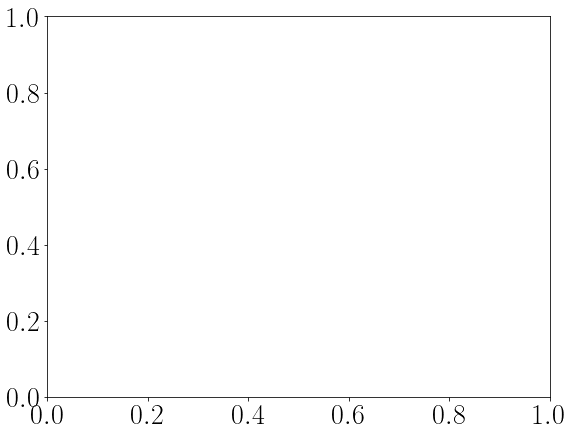

In [159]:
# Create a larger figure and adjust the layout
fig, axes = plt.subplots(1, 1, figsize=(9, 7))
x,y= 198,198
# Plot the real part of the eigenvalues
scatter1 = axes.plot(t, gamma_t[:,x,y],c='b')
axes.set_xlabel('$t/\pi$', fontsize=26)

axes.set_ylabel(rf"$D_{{{x},{y}}}$", fontsize=26)
axes.tick_params(axis='both', which='major', labelsize=26)
xticks = [0, 10*np.pi, 20*np.pi, 30 * np.pi]

# Set the x-ticks
axes.set_xticks(xticks)
axes.set_xticklabels([f'{val/np.pi:.2f}' for val in xticks])
axes.set_xlim(min(t)-1, max(t))

plt.tight_layout()

# Set global font size and LaTeX rendering
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 28,
})
# plt.savefig(home_data + f"Gamma_{x}_{y}_{size}.png", format='png', bbox_inches='tight', dpi=300)

In [11]:

import matplotlib.pyplot as plt

def plot_density_heatmap(GAMMA, t_axis=None, cmap="coolwarm",
                         vmin=0.0, vmax=1.0, cbar_label=r"$n(x,t)=C_{x,x}(t)$",
                         yticks=None):
    """
    Plot heatmap of n(x,t) = C_{x,x}(t).

    GAMMA : array of shape (T, N, N)  OR  (T, N*N) with row-stacking (index = j + i*N)
    t_axis: optional 1D array of length T for labeling the time axis
    cmap  : matplotlib colormap
    vmin, vmax: color scale limits
    cbar_label: colorbar label
    yticks: optional tick locations for time axis (only used if t_axis is given)
    """
    GAMMA = np.asarray(GAMMA)
    if GAMMA.ndim != 3 :
        raise ValueError("GAMMA must have shape (T,N,N) or (T,N*N,1).")

    T = GAMMA.shape[0]
    _, N, N2 = GAMMA.shape
    # Extract n(x,t) depending on the input format
    if GAMMA.ndim == 3:
        if N2==1:
            # (T, N*N, 1) row-stacked -> take indices i*(N+1)
            TN = GAMMA.shape[1]
            N = int(np.sqrt(TN))
            if N*N != TN:
                raise ValueError("For (T,N*N) input, second dim must be a perfect square.")
            diag_idx = np.arange(0, N*(N+1), N+1)  # i*(N+1)
            n_xt = GAMMA[:, diag_idx]  # (T,N)
       -
        if N == N2:
            n_xt = np.diagonal(GAMMA, axis1=1, axis2=2)  # (T,N)

    n_xt = np.real_if_close(n_xt)

    fig, ax = plt.subplots(figsize=(9, 6))

    if t_axis is None:
        im = ax.imshow(n_xt, origin="lower", aspect="auto",
                       vmin=vmin, vmax=vmax, cmap=cmap)
        ax.set_xlabel("position $x$")
        ax.set_ylabel("time index")
    else:
        t_axis = np.asarray(t_axis)
        if t_axis.shape[0] != T:
            raise ValueError("t_axis must have length T = GAMMA.shape[0].")
        im = ax.imshow(n_xt, origin="lower", aspect="auto",
                       extent=[0, N-1, t_axis[0], t_axis[-1]],
                       vmin=vmin, vmax=vmax, cmap=cmap)
        ax.set_xlabel("$x$")
        ax.set_ylabel("$t$")
        if yticks is not None:
            ax.set_yticks(yticks)
            ax.set_yticklabels([f"{val/np.pi:.2f}" for val in yticks])

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label, labelpad=15)

    plt.tight_layout()
    return fig, ax



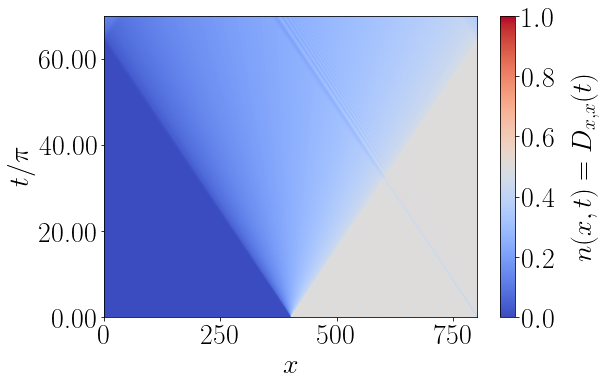

In [86]:
# If you have a time array t of length T (like your earlier code):
fig, ax = plot_density_heatmap(gamma_t, t_axis=t, cmap="coolwarm")
# ax.set_ylim(0,50*np.pi)
# Save the figure as PDF  
# plt.savefig(home_data + f"NE_Transport_{size}.png", format='png', bbox_inches='tight', dpi=300)

/opt/homebrew/lib/python3.9/site-packages/matplotlib/collections.py:206: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


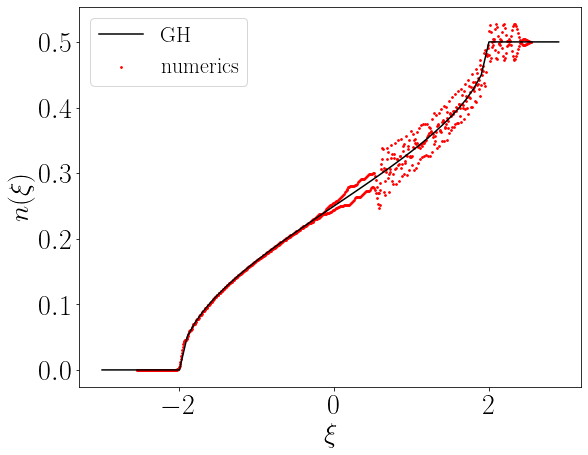

In [113]:
# Re-scaled Local observable 
position = np.arange(-size,size)
zeta= position/t_zeta # rescaled ray

Gamma_t_zeta_D= np.diag(gamma_t_zeta)


fig, axes = plt.subplots(1, 1, figsize=(9, 7))
axes.scatter(zeta,Gamma_t_zeta_D, s=3, c='r', label='numerics')
axes.set_xlabel(r'$ \xi $')
axes.set_ylabel(r'$n(\xi)$')
n= np.arange(-3,3,0.1)
N= n_zeta(n)
axes.plot(n,N, c='black', label='GH')
axes.legend(fontsize=22)
plt.savefig(home_data + f"n_GHD_{size}.png", format='png', bbox_inches='tight', dpi=300)


/opt/homebrew/lib/python3.9/site-packages/matplotlib/collections.py:206: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


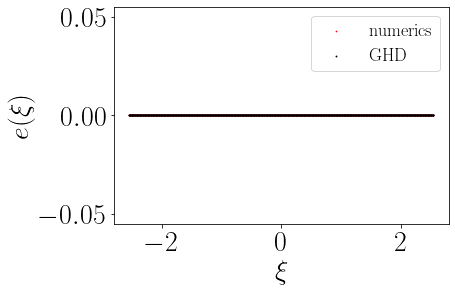

In [114]:
# local energy density

E_zeta= np.diag(gamma_t_zeta, k=1) +np.diag(gamma_t_zeta,k=-1)
zeta_e= zeta[:-1]
e_Zeta= e_zeta(zeta_e)

plt.scatter(zeta_e, E_zeta, c='red', s=0.5, label='numerics')
plt.scatter(zeta_e, e_Zeta, c='black', s=0.8, label='GHD')
plt.xlabel(r'$\xi$')
plt.ylabel(r'$e(\xi)$')
plt.legend(fontsize=18)
plt.savefig(home_data + f"e_GHD_{size}.png", format='png', bbox_inches='tight', dpi=300)

In [25]:


def J_from_gamma(gamma, j, n, bc="open"):
    """
    Compute J for general n (0 <= n < N) from a (N,N) correlator matrix gamma
    with entries gamma[a,b] = <psi| c_a^\dagger c_b |psi>.

    For n == 0:
        J = 4*( gamma[j+1, j] + gamma[j-1, j] )

    For n > 0:
        J = gamma[j+1,   j+n] + gamma[j-1,   j+n] \
          + gamma[j+n+1, j  ] + gamma[j+n-1, j  ]

    Parameters
    ----------
    gamma : ndarray, shape (N, N)
    j     : int or array-like of ints (sites in [0, N-1])
    n     : int, 0 <= n < N
    bc    : "open" or "periodic"

    Returns
    -------
    J : scalar or ndarray (same shape as j), dtype = gamma.dtype
    """
    gamma = np.asarray(gamma)
    N = gamma.shape[0]
    assert gamma.shape == (N, N), "gamma must be (N, N)"
    assert 0 <= n < N, "require 0 <= n < N"

    j = np.asarray(j)

    if bc == "periodic":
        jp = (j + 1) % N
        jm = (j - 1) % N
        if n == 0:
            val = 4 * (gamma[jp, j] + gamma[jm, j])
        else:
            jnp = (j + n) % N
            jnpp = (j + n + 1) % N
            jnpm = (j + n - 1) % N
            val = gamma[jp, jnp] + gamma[jm, jnp] + gamma[jnpp, j] + gamma[jnpm, j]

    elif bc == "open":
        # neighbors (safe-clipped indices; we'll mask out-of-bounds)
        jp = j + 1
        jm = j - 1

        if n == 0:
            mp = (jp >= 0) & (jp < N)
            mm = (jm >= 0) & (jm < N)
            jp_s = np.clip(jp, 0, N - 1)
            jm_s = np.clip(jm, 0, N - 1)
            val = 4 * (mp * gamma[jp_s, j] + mm * gamma[jm_s, j])
        else:
            jnp  = j + n
            jnpp = j + n + 1
            jnpm = j + n - 1

            m1 = (jp   >= 0) & (jp   < N) & (jnp  >= 0) & (jnp  < N)
            m2 = (jm   >= 0) & (jm   < N) & (jnp  >= 0) & (jnp  < N)
            m3 = (jnpp >= 0) & (jnpp < N)
            m4 = (jnpm >= 0) & (jnpm < N)

            jp_s   = np.clip(jp,   0, N - 1)
            jm_s   = np.clip(jm,   0, N - 1)
            jnp_s  = np.clip(jnp,  0, N - 1)
            jnpp_s = np.clip(jnpp, 0, N - 1)
            jnpm_s = np.clip(jnpm, 0, N - 1)

            term1 = np.where(m1, gamma[jp_s,  jnp_s], 0)
            term2 = np.where(m2, gamma[jm_s,  jnp_s], 0)
            term3 = np.where(m3, gamma[jnpp_s, j],    0)
            term4 = np.where(m4, gamma[jnpm_s, j],    0)
            val = term1 + term2 + term3 + term4
    else:
        raise ValueError("bc must be 'open' or 'periodic'")

    # Return scalar if j was scalar
    return val.item() if val.shape == () else val


/opt/homebrew/lib/python3.9/site-packages/matplotlib/collections.py:206: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


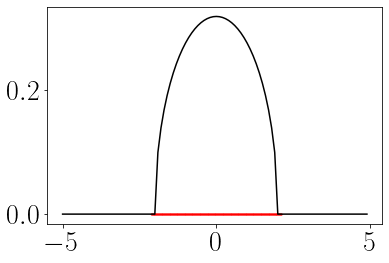

In [35]:
indeces= np.arange(2*size)
n= np.arange(-5,5,0.1)
j_n0_zeta= J_from_gamma(gamma_t_zeta,indeces,0, 'periodic' )
j_zeta = J_zeta(n)

plt.plot(n,j_zeta, c='black')
plt.scatter(zeta,j_n0_zeta, s=0.2, c='r')

In [333]:
# Entanglement Entropy GHD
X1= 0
X2= 90
t_solid= np.arange(0,50*np.pi,0.1)
EE= np.array([EE_disjoint(T, X1, X2, delta_k=1e-3, return_parts=False) for T in t_solid])
EE= EE/(X2)


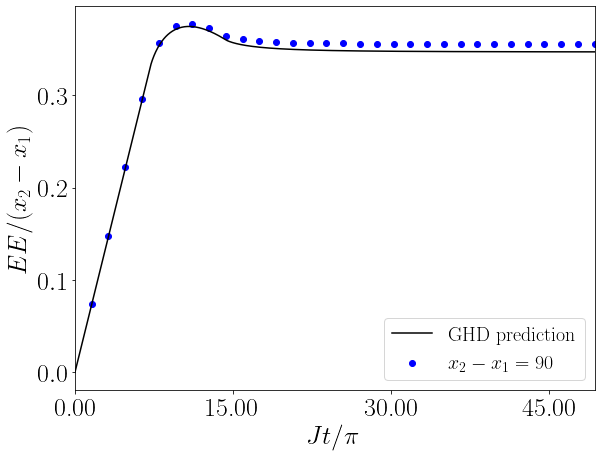

In [334]:
# Create a larger figure and adjust the layout
fig, axes = plt.subplots(1, 1, figsize=(9, 7))

# Plot the real part of the eigenvalues
axes.scatter(t, ee_t/X2,c='b',label=f"$x_2-x_1={X2}$")
axes.plot(t_solid, EE, c='black', label='GHD prediction')
axes.set_xlabel('$Jt/\pi$', fontsize=26)
axes.set_ylabel('$EE/(x_2-x_1)$', fontsize=26)
axes.tick_params(axis='both', which='major', labelsize=26)
xticks = [0, 15*np.pi, 30*np.pi,  45* np.pi]

# Set the x-ticks
axes.set_xticks(xticks)
axes.set_xticklabels([f'{val/np.pi:.2f}' for val in xticks])
axes.set_xlim(min(t), max(t))
axes.legend(fontsize=20)
plt.tight_layout()

# Set global font size and LaTeX rendering
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 28,
})

home_data = "/Users/juan/Desktop/Bologna/INH_QUENCH/"
ensure_directory_exists(home_data)
# Save the figure as PDF  
# plt.savefig(home_data + f"EE_GHD_size_{size}_l_{X2-X1}.png", format='png', bbox_inches='tight', dpi=300)


In [440]:
# commutator check

# Anxalytic result

def build_com(C, bc):
    """
    Compute 'com' from C[a,b] on an N x N grid.

    Parameters
    ----------
    C  : ndarray (N,N)
    bc : {'open','periodic'}
        - 'open': out-of-range neighbors contribute 0
        - 'periodic': wrap indices modulo N

    Returns
    -------
    com : ndarray (N,N)
    """
    C = np.asarray(C)
    N = C.shape[0]
    assert C.shape == (N, N), "C must be (N,N)"
    l, m = np.indices((N, N))  # grids of indices

    diag = np.diag(C)          # (N,)

    if bc == "periodic":
        l_p1 = (l + 1) % N
        l_m1 = (l - 1) % N
        m_p1 = (m + 1) % N
        m_m1 = (m - 1) % N

        term_lplus  = C[l_p1, m]
        term_lminus = C[l_m1, m]
        term_mplus  = C[l, m_p1]
        term_mminus = C[l, m_m1]

        core = (term_lplus + term_lminus - term_mplus - term_mminus) 


        return core 

    elif bc == "open":
        lm = (l - 1 >= 0); lp = (l + 1 < N)
        mm = (m - 1 >= 0); mp = (m + 1 < N)

        l_p1 = np.clip(l + 1, 0, N - 1)
        l_m1 = np.clip(l - 1, 0, N - 1)
        m_p1 = np.clip(m + 1, 0, N - 1)
        m_m1 = np.clip(m - 1, 0, N - 1)

        term_lplus  = np.where(lp, C[l_p1, m], 0.0)
        term_lminus = np.where(lm, C[l_m1, m], 0.0)
        term_mplus  = np.where(mp, C[l, m_p1], 0.0)
        term_mminus = np.where(mm, C[l, m_m1], 0.0)

        core = (term_lplus + term_lminus - term_mplus - term_mminus) 

#         return core + boundary
        return core 

    else:
        raise ValueError("bc must be 'open' or 'periodic'")

    


In [18]:

# --- Matrix→Vector reshaping (column-stacking) ---
def mat2vec(C):
    """
    Vectorize a matrix C into a column vector |M>  (row-stacking order).
    Equivalent to np.reshape(C, (N**2, 1), order='C') 
    """
    return C.reshape(-1, 1, order='C')   # row-major order; see note below


# --- Pre-multiplication superoperator: A ρ  →  (A ⊗ I) |ρ>  ---
def spre(A):
    """
    Superoperator for pre-multiplication by A:  A ρ → (A ⊗ I) |ρ>.
    """
    A = np.asarray(A)
    N, N2 = A.shape
    assert N == N2, "spre(): input must be a square (N,N) matrix."
    return np.kron(A, np.eye(N))


# --- Post-multiplication superoperator: ρ A  →  (I ⊗ Aᵗ) |ρ>  ---
def spost(A):
    """
    Superoperator for post-multiplication by A:  ρ A → (I ⊗ Aᵗ) |ρ>.
    """
    A = np.asarray(A)
    N, N2 = A.shape
    assert N == N2, "spost(): input must be a square (N,N) matrix."
    return np.kron(np.eye(N), A.T)

#generate Liouvillian using pre and post 

def liouvillian(L, P,gamma):
    """
    Build vectorized Liouvillian for dC/dt = L C - C L† +2\gamma P C P.

    Parameters
    ----------
    L : (N,N) complex array
    P : (N,N) projector matrix
    gamma: measurement rate

    Returns
    -------
    L_sup : (N**2, N**2) matrix
    """
    return spre(L) + spost(L.conj().T) + (2*gamma)*(spre(P) @ spost(P)) 



def projector(L, size, bc, dtype=float):
    """
    Build a projection operator P ∈ C^{N×N} acting as identity
    on region A = [-|L|, |L|] centered at `size`, and 0 elsewhere.

    Parameters
    ----------
    L   : int
        Half-length of region A (inclusive, so region width = 2L + 1)
    size : int
        Half-system size (so total system N = 2*size)
    bc  : str, {'open', 'periodic'}
        Boundary condition: open or periodic.
    dtype : type, optional
        Data type of matrix entries (default float).

    Returns
    -------
    P : ndarray (N, N)
        Projector matrix. P[i,j] = δ_{ij} if site i∈A, else 0.
    """
    N = 2 * size
    L = abs(L)

    diag = np.zeros(N, dtype=dtype)
    center = size

    if bc == 'open':
        # region stays within 0..N-1, truncated at boundaries
        lo = max(0, center - L)
        hi = min(N - 1, center + L)
        diag[lo:hi + 1] = 1.0

    elif bc == 'periodic':
        # wrap indices around using modulo arithmetic
        idx = (np.arange(center - L, center + L + 1) % N)
        diag[idx] = 1.0

    else:
        raise ValueError("bc must be 'open' or 'periodic'")

    return np.diag(diag)


def projector_HZ(L, bc):
    """
    Build a projection operator P ∈ C^{N×N} acting as identity
    on region A = [0, L] 

    Parameters
    ----------
    L   : int
        Length of region A 
    bc  : str, {'open', 'periodic'}
        Boundary condition: open or periodic.

    Returns
    -------
    P : ndarray (N, N)
        Projector matrix. P[i,j] = δ_{ij} if site i∈A, else 0.
    """
    
    op= np.array([[0,0], [0,1]])
    ez= np.eye(L)
    if bc == 'open':
        P= np.kron(op,ez)
    if bc == 'periodic':
        P= np.kron(op,ez)
        P[-1][0]= P[0][-1]= 1
        
    return P

In [13]:
# check
A = np.array([[1, 2],
              [3, 4]], dtype=float)
B = np.array([[5, 6],
              [7, 8]], dtype=float)
C = np.array([[9, 10],
              [11, 12]], dtype=float)

vecACB = mat2vec(A @ C @ B)
rhs = np.kron(A, B.T) @ mat2vec(C)

print(np.allclose(vecACB, rhs))  # ✅ should be True

True


In [35]:
# Extensive measurement dynamics

size= 30
T1= 1
Mu=0
gamma= 0.5
BD= 'open'
# Initial state
C_0 = Gamma_0(size)
vecC0= mat2vec(C_0)
# subregion A size [-|L|,|L|]
L= 7
x1,x2= -L,L
# Quench Hamiltonian
h= Hamiltonian(size, T1, Mu, BD)
# Non-Hermitian term

# Projector on  A= [-|L|,|L|]
# P= projector(L, size, BD, dtype=float)
# Half size projector operator A=[0,size]
P =projector_HZ(size,BD)

# conditional Hamiltonian
h_cond= 1j*h-gamma*P

# vectorized Liouvilian
L_sup = liouvillian(h_cond, P,gamma)


print('L_sup is done')


L_sup is done


In [36]:
T= np.arange(0,3*np.pi,0.3)
# T=[50]
vecC_t = np.array([LA.expm(L_sup * t) @ vecC0 for t in T])
# C_t= np.array([Gamma_t(C_0, h, step) for step in T ])

print('time evolution is done')

time evolution is done


0.5

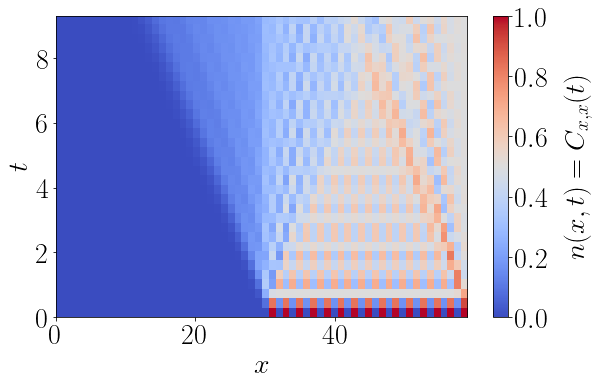

In [37]:
# If you have a time array t of length T (like your earlier code):
fig, ax = plot_density_heatmap(vecC_t, t_axis=T, cmap="coolwarm",vmin=0.0, vmax=1.0, \
                               cbar_label=r"$n(x,t)=C_{x,x}(t)$",yticks=None)
# ax.set_ylim(0,50*np.pi)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 28,
})
# Save the figure as PDF  
home_data = "/Users/juan/Desktop/Bologna/INH_QUENCH/"
ensure_directory_exists(home_data)
# plt.savefig(home_data + f"NE_Transport_{size}_Gamma{gamma}_L{L}.png", format='png', bbox_inches='tight', dpi=300)
plt.savefig(home_data + f"NE_Transport_{size}_Gamma{gamma}_L{size}.png", format='png', bbox_inches='tight', dpi=300)
gamma

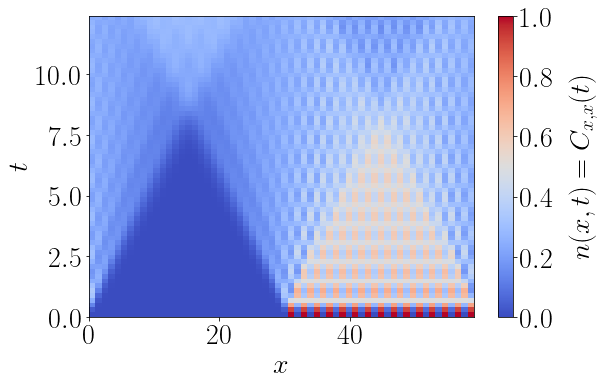

In [634]:
# If you have a time array t of length T (like your earlier code):
fig, ax = plot_density_heatmap(C_t, t_axis=T, cmap="coolwarm",vmin=0.0, vmax=1.0, \
                               cbar_label=r"$n(x,t)=C_{x,x}(t)$",yticks=None)
# ax.set_ylim(0,50*np.pi)
# Save the figure as PDF  
# plt.savefig(home_data + f"NE_Transport_{size}.png", format='png', bbox_inches='tight', dpi=300)